   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

/tmp/ipykernel_744/3224155700.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)


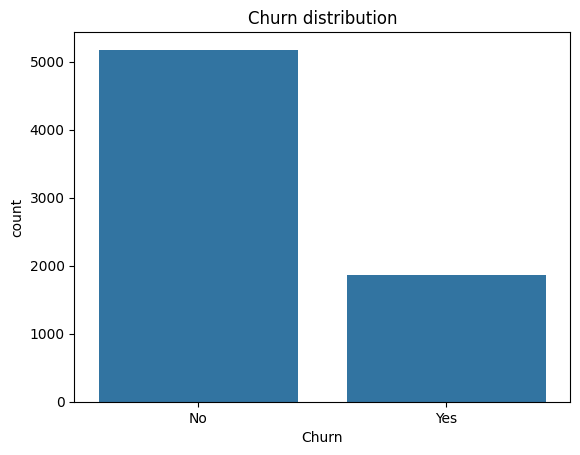

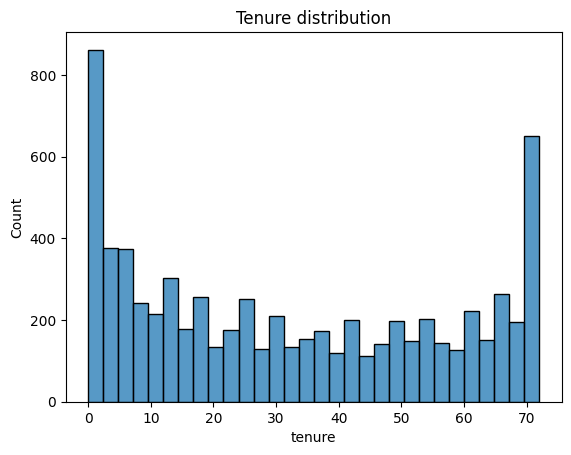

(7043, 31)
(5634, 30)
(1409, 30)


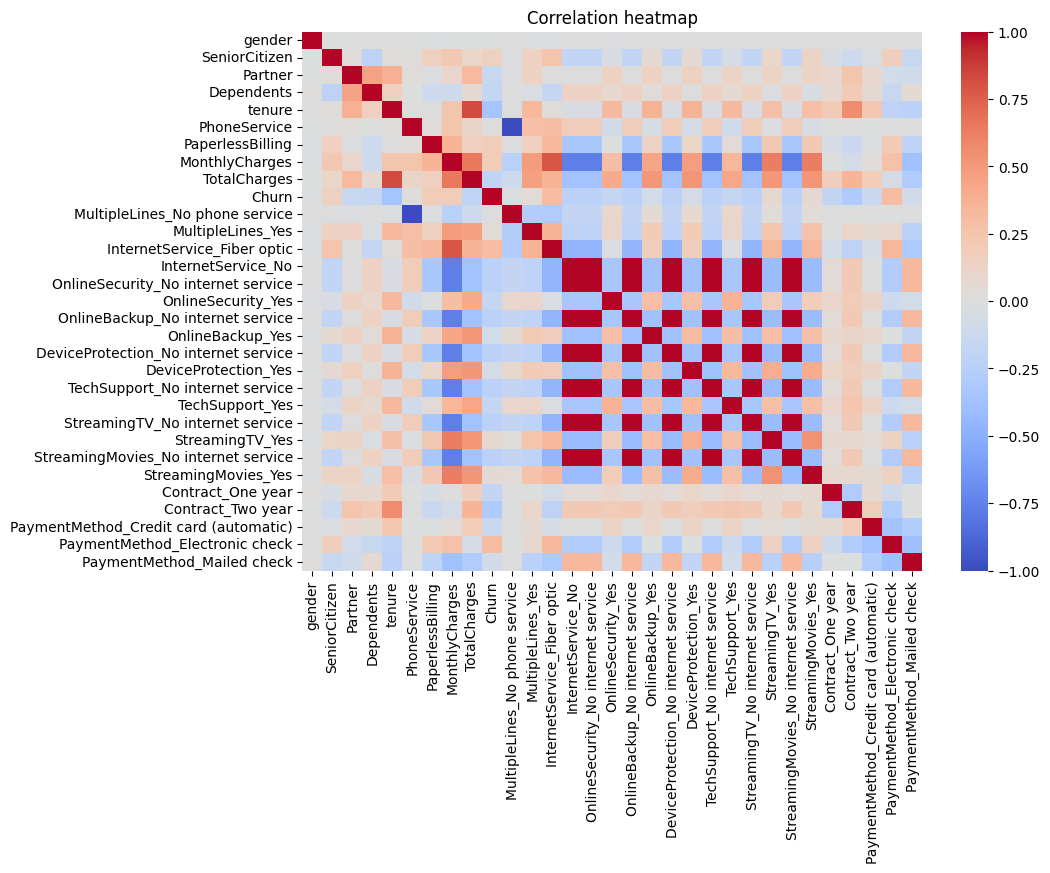

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# loading dataset
data = pd.read_csv("Telco-Customer-Churn dataset.csv")

# quick look
print(data.head())

# dataset shape
print(data.shape)

# column names
print(data.columns)

# dataset info
print(data.info())

# checking missing values
print(data.isnull().sum())

# removing customer id
data = data.drop("customerID", axis=1)

# fixing TotalCharges column
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# check missing again
print(data.isnull().sum())

# filling missing values
data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)

# check again
print(data.isnull().sum())

# checking churn distribution
print(data["Churn"].value_counts())

# simple churn plot
sns.countplot(x="Churn", data=data)
plt.title("Churn distribution")
plt.show()

# tenure distribution
sns.histplot(data["tenure"], bins=30)
plt.title("Tenure distribution")
plt.show()

# encoding binary columns
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == "object":
        if data[col].nunique() == 2:
            data[col] = le.fit_transform(data[col])

# one hot encoding for remaining columns
data = pd.get_dummies(data, drop_first=True)

print(data.shape)

# split features and target
X = data.drop("Churn", axis=1)
y = data["Churn"]

# scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

# quick correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()



# ---------------- OUTPUTS ----------------

# data.head()
#   customerID  gender  SeniorCitizen Partner Dependents tenure PhoneService ...
#   7590-VHVEG  Female  0             Yes     No         1      No
#   5575-GNVDE  Male    0             No      No         34     Yes
#   3668-QPYBK  Male    0             No      No         2      Yes
#   ...

# data.shape
# (7043, 21)

# data.columns
# Index(['customerID','gender','SeniorCitizen','Partner','Dependents','tenure',
# 'PhoneService','MultipleLines','InternetService','OnlineSecurity',
# 'OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
# 'StreamingMovies','Contract','PaperlessBilling','PaymentMethod',
# 'MonthlyCharges','TotalCharges','Churn'], dtype='object')

# missing values before cleaning
# TotalCharges    11

# missing after filling
# TotalCharges    0

# churn value counts
# No     5174
# Yes    1869

# shape after encoding
# (7043, 30)

# X_train shape
# (5634, 29)

# X_test shape
# (1409, 29)